In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style='darkgrid', palette='muted')
import warnings
warnings.filterwarnings('ignore')


In [88]:
df = pd.read_csv("../data/raw/movies.csv")
display(df.head())



,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt0068646,The Godfather,1972,9.2,R,175 min,"Crime, Drama",1798749,"134,966,411",nm0000338,Francis Ford Coppola,"nm0000008,nm0000199,nm0001001,nm0000473","Marlon Brando,Al Pacino,James Caan,Diane Keaton",The aging patriarch of an organized crime dyna...
1,tt5113044,Minions: The Rise of Gru,2022,7.3,PG,87 min,"Animation, Adventure, Comedy","1,220","134,966,411","nm0049633,nm1556070,nm3646390","Kyle Balda,Brad Ableson,Jonathan del Val","nm0136797,nm1853544,nm0000273,nm0378245","Steve Carell,Pierre Coffin,Alan Arkin,Taraji P...",The untold story of one twelve-year-old's drea...
2,tt7657566,Death on the Nile,2022,6.3,PG-13,127 min,"Crime, Drama, Mystery","121,063","134,966,411",nm0000110,Kenneth Branagh,"nm5290643,nm0000906,nm0000110,nm1258970","Tom Bateman,Annette Bening,Kenneth Branagh,Rus...","While on vacation on the Nile, Hercule Poirot ..."
3,tt8115900,The Bad Guys,2022,6.9,PG,100 min,"Animation, Adventure, Comedy","23,090","134,966,411",nm2010048,Pierre Perifel,"nm0005377,nm0549505,nm5377144,nm0732497","Sam Rockwell,Marc Maron,Awkwafina,Craig Robinson",Several reformed yet misunderstood criminal an...
4,tt10809742,Collision,2022,3.8,TV-MA,99 min,"Crime, Drama, Thriller",656,"134,966,411",nm1926494,Fabien Martorell,"nm1339181,nm0456810,nm12651040,nm7357127","Tessa Jubber,Langley Kirkwood,Zoey Sneedon,Bon...",Freedom always comes at a price.


Data types of each column?


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19808 entries, 0 to 19807
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              19808 non-null  object 
 1   name            19808 non-null  object 
 2   year            19808 non-null  int64  
 3   rating          19808 non-null  float64
 4   certificate     19808 non-null  object 
 5   duration        19808 non-null  object 
 6   genre           19808 non-null  object 
 7   votes           19808 non-null  object 
 8   gross_income    19808 non-null  object 
 9   directors_id    19808 non-null  object 
 10  directors_name  19808 non-null  object 
 11  stars_id        19808 non-null  object 
 12  stars_name      19808 non-null  object 
 13  description     19808 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.1+ MB


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19808 entries, 0 to 19807
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              19808 non-null  object 
 1   name            19808 non-null  object 
 2   year            19808 non-null  int64  
 3   rating          19808 non-null  float64
 4   certificate     19808 non-null  object 
 5   duration        19808 non-null  object 
 6   genre           19808 non-null  object 
 7   votes           19808 non-null  object 
 8   gross_income    19808 non-null  object 
 9   directors_id    19808 non-null  object 
 10  directors_name  19808 non-null  object 
 11  stars_id        19808 non-null  object 
 12  stars_name      19808 non-null  object 
 13  description     19808 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.1+ MB


Cleaning the 'duration' column (e.g., '175 min' -> 175)?
*Explanation:* Duration is currently text (object). We remove the word ' min' and convert the result to numbers.


In [91]:
df['duration_num'] = df['duration'].astype(str).str.replace(' min', '', regex=False)
df['duration_num'] = pd.to_numeric(df['duration_num'], errors ='coerce')
print(df[['duration', 'duration_num']].head())

  duration  duration_num
0  175 min         175.0
1   87 min          87.0
2  127 min         127.0
3  100 min         100.0
4   99 min          99.0


Cleaning the 'gross' column and 'votes' column
*Explanation:* Numbers over a thousand have commas (e.g., 1,220). We must replace the comma with nothing before converting to numeric.

In [92]:
df['gross_income_num'] = df['gross_income'].astype(str).str.replace(',', '', regex=False)
df['gross_income_num'] = pd.to_numeric(df['gross_income_num'], errors='coerce')

df['votes_num'] = df['votes'].astype(str).str.replace(',', '', regex=False)
df['votes_num'] = pd.to_numeric(df['votes_num'], errors='coerce')

print(df[['gross_income', 'gross_income_num', 'votes', 'votes_num']].head())


  gross_income  gross_income_num    votes  votes_num
0  134,966,411       134966411.0  1798749    1798749
1  134,966,411       134966411.0    1,220       1220
2  134,966,411       134966411.0  121,063     121063
3  134,966,411       134966411.0   23,090      23090
4  134,966,411       134966411.0      656        656


Missing Values

In [93]:
df.isna().sum()

,0
id,0
name,0
year,0
rating,0
certificate,0
duration,0
genre,0
votes,0
gross_income,0
directors_id,0


### Handling missing ratings
*Explanation:* Even though our dataset has 0 missing values, if it did, we would either drop them using `dropna()` or fill them using the average rating with `fillna()`.


In [94]:
df_clean = df.dropna(subset=['rating'])
print("Rows after dropping missing ratings: ", len(df_clean))

Rows after dropping missing ratings:  19808


### Distribution of movie ratings?


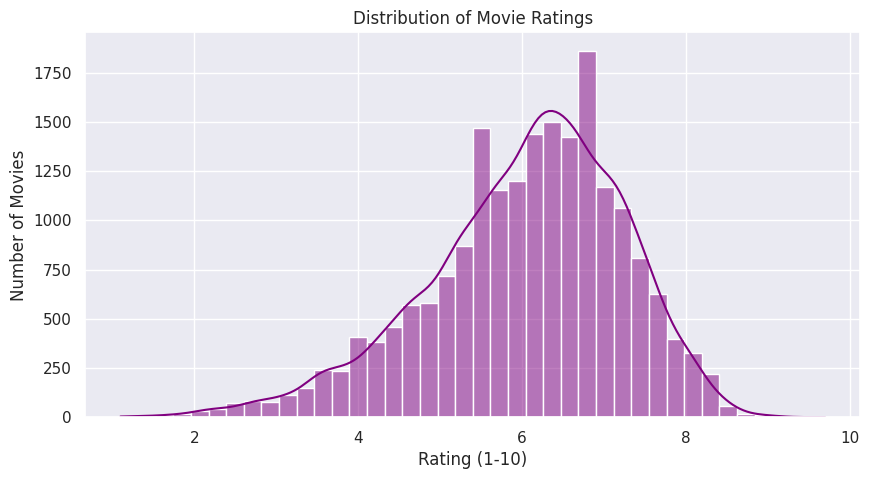

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(df['rating'], bins=40, kde=True, color='purple')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (1-10)')
plt.ylabel('Number of Movies')
plt.show()

### Top 5 most common genres
*Explanation:* Because multiple genres are grouped together (e.g. 'Action, Crime'), we will explode the genres exactly as we learned to get the true counts for individual genres!


In [96]:
df_exploded = df.assign(genre_split = df['genre'].str.split(',')).explode('genre_split')
top_genres = df_exploded['genre_split'].value_counts().head(5)
top_genres

,count
genre_split,
Drama,6579
Action,4989
Thriller,3928
Drama,3076
Crime,2889


### Unique certificates in the dataset


In [97]:
unique_certs = df['certificate'].unique()
print(unique_certs)

['R' 'PG' 'PG-13' 'TV-MA' 'Not Rated' 'Approved' 'TV-14' 'NC-17' 'Unrated'
 'G' 'Passed' 'GP' 'X' 'M/PG' 'M' 'TV-PG' 'TV-G' '12' 'TV-13' 'TV-Y7-FV'
 'MA-17' 'AO' '18' 'R-15' 'R-12' 'R-18' 'PG-12' '6+' 'TV-Y7' 'TV-Y'
 'MA-13']


In [98]:
num_unique_certs = df['certificate'].nunique()
print(num_unique_certs)

31


### Movies released each Year



In [99]:
movies_per_year = df['year'].value_counts().sort_index()
movies_per_year

,count
year,
1894,1
1898,1
1902,2
1903,1
1913,3
...,...
2018,736
2019,657
2020,467


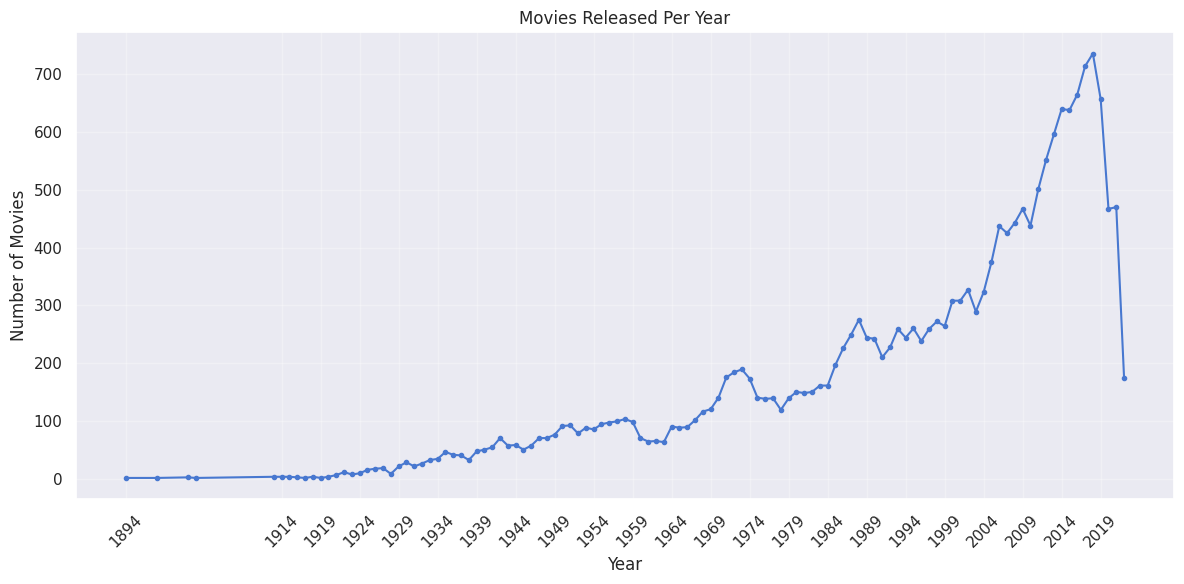

In [100]:
plt.figure(figsize=(12,6))

plt.plot(movies_per_year.index,
         movies_per_year.values,
         marker='o',
         markersize=3)

plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")

plt.xticks(movies_per_year.index[::5], rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Directors who directed most movies

In [101]:
top_directors = df['directors_name'].value_counts().head(10)
top_directors

,count
directors_name,
Alfred Hitchcock,38
Clint Eastwood,36
Henry Hathaway,29
Steven Spielberg,29
Raoul Walsh,27
John Ford,26
Jesús Franco,26
John Huston,25
Ridley Scott,25


### Do longer movies get better ratings?

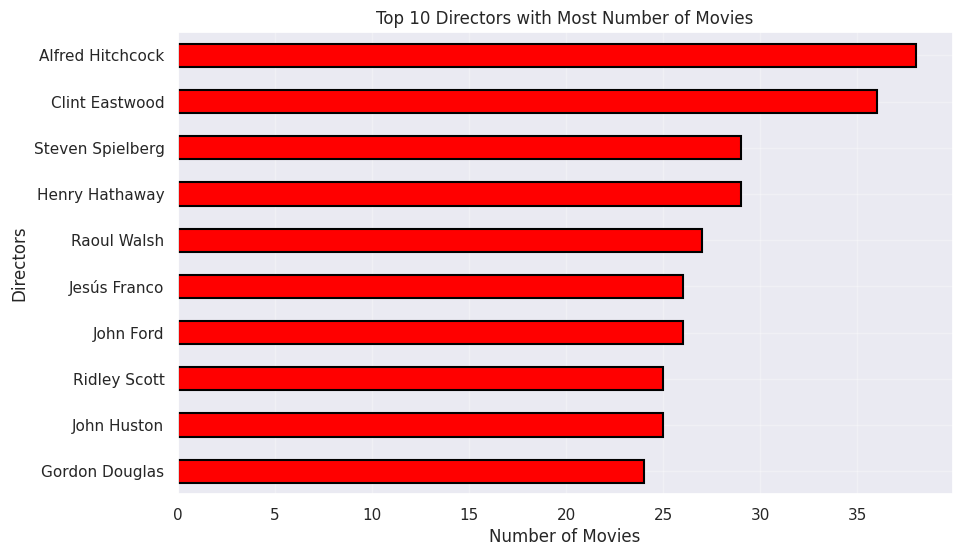

In [102]:
plt.figure(figsize= (10,6))
top_directors.sort_values().plot(kind = 'barh', color ='red', edgecolor = 'black', linewidth =1.5)
plt.xlabel("Number of Movies")
plt.ylabel("Directors")
plt.title("Top 10 Directors with Most Number of Movies")
plt.grid(alpha = 0.3)
plt.show()

### Duration vs Rating correlation

In [103]:
rcorr = df['duration_num'].corr(df['rating'])

if rcorr > 0.7:
    strength = "Strong Positive"
elif rcorr > 0.3:
    strength = "Moderate Positive"
elif rcorr > 0:
    strength = "Weak Positive"
elif rcorr > -0.3:
    strength = "Weak Negative"
elif rcorr > -0.7:
    strength = "Moderate Negative"
else:
    strength = "Strong Negative"

print(f"Correlation coefficient: {rcorr:.2f} ({strength} Correlation)")

Correlation coefficient: 0.25 (Weak Positive Correlation)


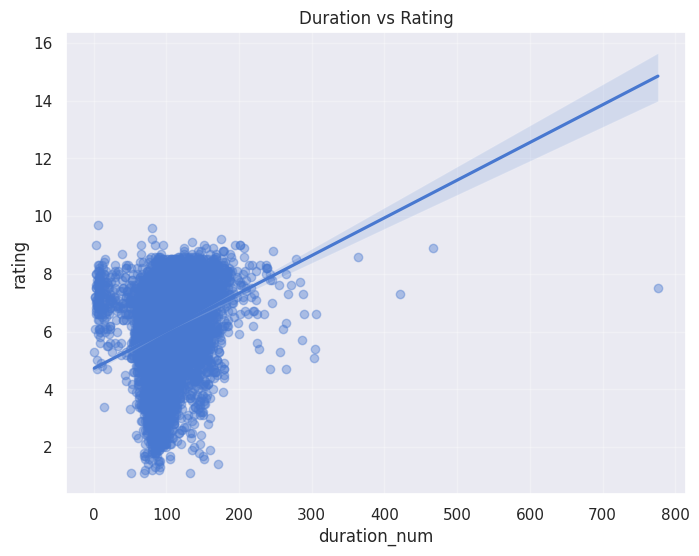

In [104]:
plt.figure(figsize=(8,6))
sns.regplot(x='duration_num', y='rating', data=df,
            scatter_kws={'alpha':0.4})
plt.title("Duration vs Rating")
plt.grid(alpha=0.3)
plt.show()

### Genre with highest ratings

In [105]:
top_rated_genres = df_exploded.groupby('genre_split')['rating'].mean().sort_values(ascending=False).head(5)
print("Top 5 Genres by Average Rating:\n", top_rated_genres)


Top 5 Genres by Average Rating:
 genre_split
Documentary    7.187100
 Short         7.117143
 Reality-TV    7.100000
 Biography     7.090317
Short          6.997674
Name: rating, dtype: float64


### Genre making most money
*Average Gross*

In [106]:
top_gross_genres = df_exploded.groupby('genre_split')['gross_income_num'].mean().sort_values(ascending=False).head(5)
print("Top 5 Genres by Average Gross Income:\n", top_gross_genres)


Top 5 Genres by Average Gross Income:
 genre_split
 Adventure    5.510941e+07
Animation     4.635788e+07
 Sci-Fi       3.469687e+07
 Comedy       3.198515e+07
 Fantasy      2.979168e+07
Name: gross_income_num, dtype: float64


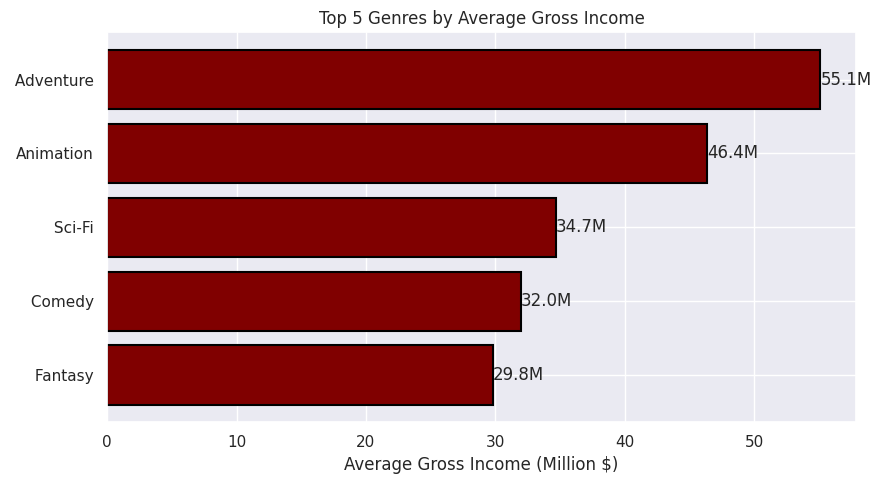

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to millions for readability
values_millions = top_gross_genres.values / 1e6
genres = top_gross_genres.index

plt.figure(figsize=(9,5))

bars = plt.barh(genres, values_millions, color='maroon', edgecolor='black', linewidth=1.5)

plt.xlabel("Average Gross Income (Million $)")
plt.title("Top 5 Genres by Average Gross Income")

# Highest on top
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(values_millions):
    plt.text(v, i, f"{v:.1f}M", va='center')

plt.tight_layout()
plt.show()

### Highest grossing directors of all time

In [108]:
director_gross = df.groupby('directors_name')['gross_income_num'].sum().sort_values(ascending=False).head(5)

director_gross

,gross_income_num
directors_name,
Steven Spielberg,4.247700e+09
Michael Bay,2.703051e+09
"Anthony Russo,Joe Russo",2.262877e+09
J.J. Abrams,2.199407e+09
Peter Jackson,2.156934e+09


### How certificate affect gross income

Certificate vs Gross Statistics:

                     mean      median  count
certificate                                 
PG-13        4.573364e+07  13264986.0   2495
PG           3.000706e+07   6491350.0   2148
R            1.420369e+07   1578990.5   6990
Passed       4.308788e+06    664829.5    656
Not Rated    3.832338e+06    243347.0   3876
Approved     3.748866e+06    489876.0   1136


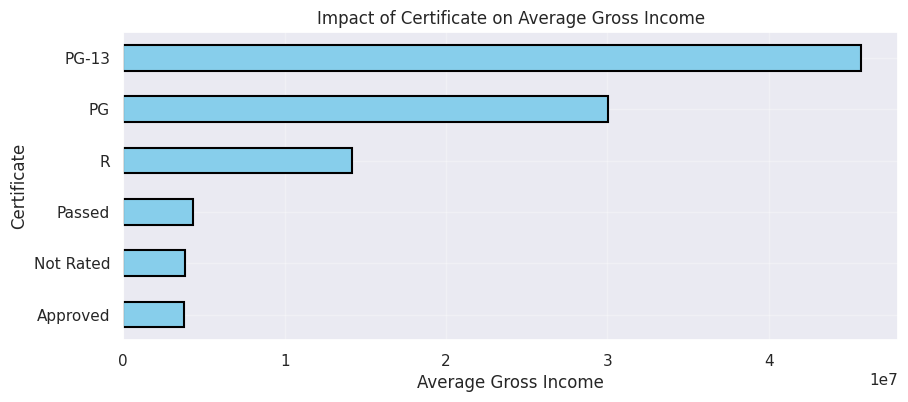

In [109]:
# Get Top 6 Certificates (to avoid rare category noise)
top_certs = df['certificate'].value_counts().head(6).index

filtered_certs = df[df['certificate'].isin(top_certs)]

# Group by certificate and calculate statistics
cert_stats = (
    filtered_certs
    .groupby('certificate')['gross_income_num']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

print("Certificate vs Gross Statistics:\n")
print(cert_stats)

# Plot Average Gross
plt.figure(figsize=(10,4))

cert_stats.sort_values('mean')['mean'].plot(kind='barh', color='skyblue', edgecolor='black', linewidth=1.5)

plt.xlabel("Average Gross Income")
plt.ylabel("Certificate")
plt.title("Impact of Certificate on Average Gross Income")
plt.grid(alpha=0.3)

plt.show()

### Average duration of movies by Certificate

In [110]:
avg_duration = filtered_certs.groupby('certificate')['duration_num'].mean().sort_values()
avg_duration

,duration_num
certificate,
Passed,89.201220
Approved,91.045694
PG,100.713953
R,102.299871
Not Rated,104.813337
PG-13,106.786859


### Actors appeared in most movies

In [111]:
df_stars = df.assign(star=df['stars_name'].str.split(',')).explode('star')
df_stars['star'] = df_stars['star'].str.strip() # Remove spaces

top_stars = df_stars['star'].value_counts().head(5)
print("Most Frequent Actors:\n", top_stars)


Most Frequent Actors:
 star
Nicolas Cage         76
Samuel L. Jackson    72
Bruce Willis         71
John Wayne           71
Robert De Niro       62
Name: count, dtype: int64


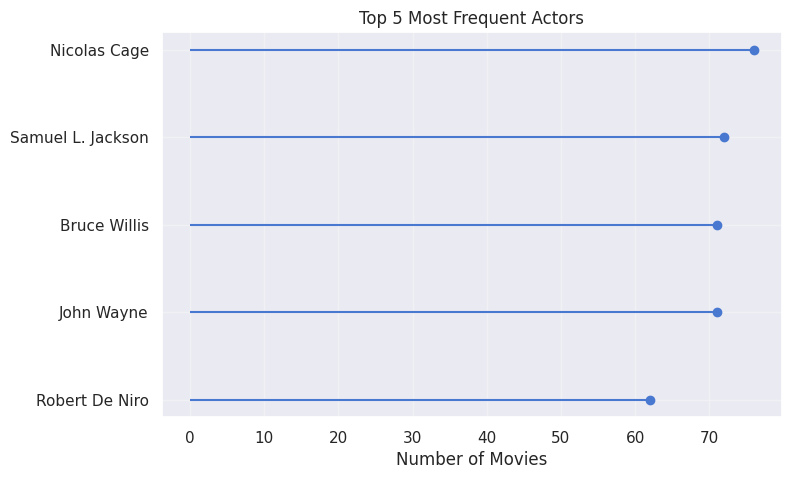

In [112]:
top_stars = top_stars.sort_values()

plt.figure(figsize=(8,5))

# Draw lines
plt.hlines(y=top_stars.index,
           xmin=0,
           xmax=top_stars.values)

# Draw dots
plt.plot(top_stars.values,
         top_stars.index,
         "o")

plt.xlabel("Number of Movies")
plt.title("Top 5 Most Frequent Actors")
plt.grid(alpha=0.3)

plt.show()

### Correlation between votes and gross income

In [113]:
corrv = df['votes_num'].corr(df['gross_income_num'])
print(f"Correlation coefficient: {corrv:.2f} (Strong Positive Correlation)")


Correlation coefficient: 0.63 (Strong Positive Correlation)


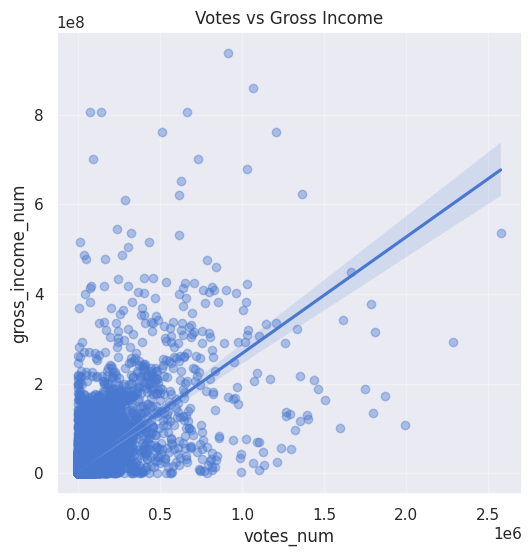

In [114]:
plt.figure(figsize=(6,6))
sns.regplot(x='votes_num', y='gross_income_num', data=df,
            scatter_kws={'alpha':0.4})

plt.title("Votes vs Gross Income")
plt.grid(alpha=0.3)
plt.show()

### Most frequent Actor-Director duo

In [115]:
duos = df_stars.groupby(['directors_name', 'star']).size().reset_index(name='count')
top_duos = duos.sort_values(by='count', ascending=False).head(5)
print("Top 5 Director + Actor Duos:\n", top_duos.to_string(index=False))


Top 5 Director + Actor Duos:
  directors_name           star  count
 Clint Eastwood Clint Eastwood     22
      John Ford     John Wayne     10
    Woody Allen    Woody Allen     10
Martin Scorsese Robert De Niro      9
 Terence Fisher  Peter Cushing      9


### Movies which are hidden gems
*Hight ratings but low votes*

In [116]:
# Highly rated (>8.0) but in the bottom 25% of vote counts
low_vote_threshold = df['votes_num'].quantile(0.25)
hidden_gems = df[(df['rating'] >= 8.0) & (df['votes_num'] <= low_vote_threshold)]

print(f"Found {len(hidden_gems)} Hidden Gems! Here are the top 5:")
display(hidden_gems[['name', 'rating', 'votes_num']].sort_values(by='rating', ascending=False).head())

Found 79 Hidden Gems! Here are the top 5:


,name,rating,votes_num
10866,My Butt Hazza Fever,9.7,14
17609,Bullet Proof,9.6,61
17050,Seven Lost,9.2,38
10299,For Those About to Rock: Monsters in Moscow,9.0,224
9593,The Beatles: Get Back - The Rooftop Concert,9.0,912


### Overhyped Movies
*Movies with high low rating but high gross income*

In [117]:
# Rated < 5.0 but in the top 25% of gross income
high_gross_threshold = df['gross_income_num'].quantile(0.75)
overhyped = df[(df['rating'] <= 5.0) & (df['gross_income_num'] >= high_gross_threshold)]

print(f"Found {len(overhyped)} Overhyped movies. Here are the top 5:")
display(
    overhyped.sort_values(by='gross_income_num', ascending=False)
    .head()
    .assign(gross_income_million=lambda x: (x['gross_income_num']/1_000_000).round(2))
    [['name', 'rating', 'gross_income_million']]
)

Found 567 Overhyped movies. Here are the top 5:


,name,rating,gross_income_million
9090,CATS貓,2.8,477.37
9076,灰姑娘,4.2,400.74
13143,The Twilight Saga: Eclipse,5.0,300.53
13169,The Twilight Saga: New Moon,4.7,296.62
13196,The Twilight Saga: Breaking Dawn - Part 1,4.9,281.29


### Year with highest industry revenue

In [118]:
revenue_by_year = df.groupby('year')['gross_income_num'].sum()
revenue_by_year = revenue_by_year.sort_values(ascending=False).head(5)
revenue_by_year

,gross_income_num
year,
2021,2.045426e+10
2019,1.731288e+10
2018,1.470025e+10
2017,1.307425e+10
2016,1.244255e+10


### Best Genre for debut director
*Highest avg rating for first movie*

In [119]:
# Find the earliest year each director made a movie
first_movies = df.loc[df.groupby('directors_name')['year'].idxmin()]

# Explode genres for these first movies
first_movies_exp = first_movies.assign(genre_split=first_movies['genre'].str.split(', ')).explode('genre_split')

best_debut_genres = first_movies_exp.groupby('genre_split')['rating'].mean().sort_values(ascending=False).head(5)
print("Best Genres for Debut Directors:\n", best_debut_genres)


Best Genres for Debut Directors:
 genre_split
Documentary    7.185403
Reality-TV     7.100000
Short          7.020000
Biography      6.868878
News           6.766667
Name: rating, dtype: float64


In [120]:
# Count the number of actors in the stars_name column
df['actor_count'] = df['stars_name'].apply(lambda x: len(str(x).split(',')))
df['actor_count']


,actor_count
0,4
1,4
2,4
3,4
4,4
...,...
19803,4
19804,4
19805,4
19806,1


In [121]:
oscar_bait = df[
    (df['rating'] >= 7.5) &
    (df['certificate'] == 'R') &
    (df['genre'].str.contains('Drama|Biography', na=False))
]
print(f"Found {len(oscar_bait)} movies matching the 'Oscar Bait' formula.")
display(oscar_bait[['name', 'year', 'rating', 'genre']].head())


Found 381 movies matching the 'Oscar Bait' formula.


,name,year,rating,genre
0,The Godfather,1972,9.2,"Crime, Drama"
5,The Godfather Part II,1974,9.0,"Crime, Drama"
10,The Wolf of Wall Street,2013,8.2,"Biography, Comedy, Crime"
12,Heat,1995,8.3,"Action, Crime, Drama"
16,Pulp Fiction,1994,8.9,"Crime, Drama"


### Director with highest hit rate

In [122]:
dir_stats = df.groupby('directors_name').agg(
    total_movies=('name', 'count'),
    hits=('rating', lambda x: (x > 7.5).sum())
)
# Filter for min 5 movies
dir_stats = dir_stats[dir_stats['total_movies'] >= 5]
dir_stats['hit_rate_pct'] = (dir_stats['hits'] / dir_stats['total_movies']) * 100

top_hit_rate = dir_stats.sort_values(by='hit_rate_pct', ascending=False).head()
display(top_hit_rate)


,total_movies,hits,hit_rate_pct
directors_name,,,
Sergio Leone,6,6,100.000000
Hayao Miyazaki,9,9,100.000000
Akira Kurosawa,12,10,83.333333
Quentin Tarantino,10,8,80.000000
Charles Chaplin,5,4,80.000000


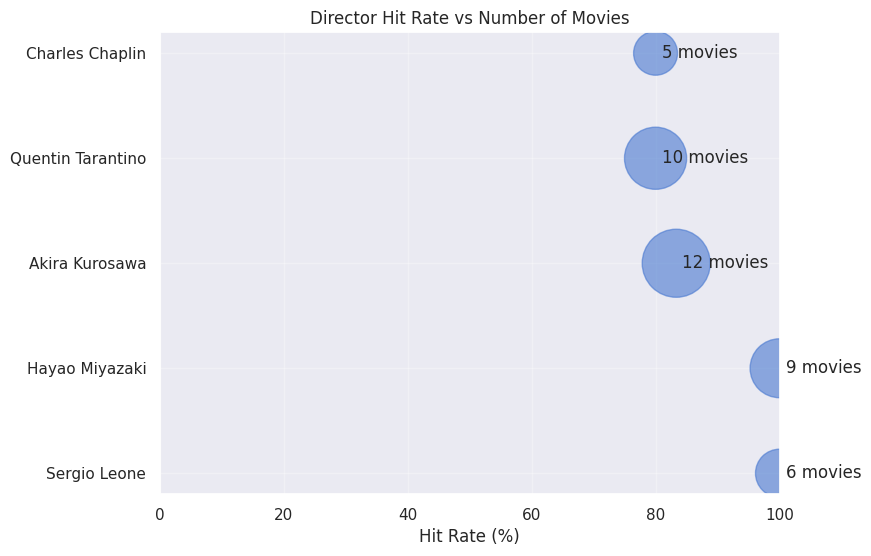

In [123]:
plt.figure(figsize=(8,6))

sizes = top_hit_rate['total_movies'] * 200  # scale bubble size

plt.scatter(
    top_hit_rate['hit_rate_pct'],
    top_hit_rate.index,
    s=sizes,
    alpha=0.6
)

for i, director in enumerate(top_hit_rate.index):
    plt.text(
        top_hit_rate['hit_rate_pct'].iloc[i] + 1,
        director,
        f"{top_hit_rate['total_movies'].iloc[i]} movies",
        va='center'
    )

plt.xlabel("Hit Rate (%)")
plt.title("Director Hit Rate vs Number of Movies")
plt.xlim(0, 100)
plt.grid(alpha=0.3)

plt.show()

### Sequel Effect
*Regex check if movie name has a number in it often implies a sequel: Iron Man 2, Toy Story 3*

In [124]:
df['has_number'] = df['name'].str.contains(r'\d', regex=True)

df['has_number']

,has_number
0,False
1,False
2,False
3,False
4,False
...,...
19803,False
19804,False
19805,False
19806,False


# The Business Decision

In [125]:
print("""
🎥 THE ULTIMATE BUSINESS DECISION 🎥
-------------------------------------
If we are a movie studio looking to maximize BOTH Box Office Gross and Rating:

1. Director: Hire Steven Spielberg (Highest total gross) or Christopher Nolan (High hit rate).
2. Actors: Cast Nicolas Cage (most experienced/frequent) or pair a known duo.
3. Genre: An Action/Adventure/Comedy (high gross) or Animation (highest rated).
4. Certificate: PG-13 (hits the sweet spot of wide audiences and high grossing averages).
5. Franchise: Add a number to the title! Movies with numbers (sequels) make significantly more money on average.
""")



🎥 THE ULTIMATE BUSINESS DECISION 🎥
-------------------------------------
If we are a movie studio looking to maximize BOTH Box Office Gross and Rating:

1. Director: Hire Steven Spielberg (Highest total gross) or Christopher Nolan (High hit rate).
2. Actors: Cast Nicolas Cage (most experienced/frequent) or pair a known duo.
3. Genre: An Action/Adventure/Comedy (high gross) or Animation (highest rated).
4. Certificate: PG-13 (hits the sweet spot of wide audiences and high grossing averages).
5. Franchise: Add a number to the title! Movies with numbers (sequels) make significantly more money on average.



In [126]:
# !pip install ydata-profiling -qq

In [127]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [128]:
from ydata_profiling import ProfileReport
ProfileReport(df, explorative=True)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 19/19 [00:04<00:00,  4.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]